In [75]:
import gcamreader
from lxml import etree
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH    = '../output'
DB_FILE    = 'database_basexdb'
QUERY_FILE = '../output/queries/Main_queries.xml'

SSP_COLORS = {
    'GCAM_SSP1': '#2ecc71',
    'GCAM_SSP2': '#3498db',
    'GCAM_SSP3': '#e74c3c',
    'GCAM_SSP4': '#f39c12',
    'GCAM_SSP5': '#9b59b6',
}

MTC_TO_GTCO2 = (44 / 12) / 1000

conn = gcamreader.querymi.LocalDBConn(DB_PATH, DB_FILE)
query_tree = etree.parse(QUERY_FILE)

available = conn.listScenariosInDB()['name'].tolist()
print('Scenarios in DB:', available)

Database scenarios: Reference, GCAM_SSP4, GCAM_SSP5, GCAM_SSP1, GCAM_SSP2, GCAM_SSP3
Scenarios in DB: ['Reference', 'GCAM_SSP4', 'GCAM_SSP5', 'GCAM_SSP1', 'GCAM_SSP2', 'GCAM_SSP3']


In [76]:
def get_query(tree, title, tag='emissionsQueryBuilder'):
    for elem in tree.getroot().iter(tag):
        if elem.get('title') == title:
            return gcamreader.querymi.Query(elem)
    raise KeyError(f'Query not found: {title}')

def query_global_co2(scenarios):
    q = get_query(query_tree, 'CO2 emissions by region')
    df = conn.runQuery(q, scenarios=scenarios)
    return (
        df.groupby(['scenario', 'Year'], as_index=False)['value']
        .sum()
        .assign(GtCO2=lambda d: d['value'] * MTC_TO_GTCO2)
        .drop(columns='value')
    )

# Pull all available scenarios
all_scenarios = [s for s in ['Reference'] + list(SSP_COLORS.keys()) if s in available]
df = query_global_co2(all_scenarios)
df.head()

,scenario,Year,GtCO2
0,"GCAM_SSP1,date=2026-25-3T11:36:00+01:00",1975,8.728588
1,"GCAM_SSP1,date=2026-25-3T11:36:00+01:00",1990,22.740105
2,"GCAM_SSP1,date=2026-25-3T11:36:00+01:00",2005,30.053722
3,"GCAM_SSP1,date=2026-25-3T11:36:00+01:00",2010,34.139211
4,"GCAM_SSP1,date=2026-25-3T11:36:00+01:00",2015,36.426925


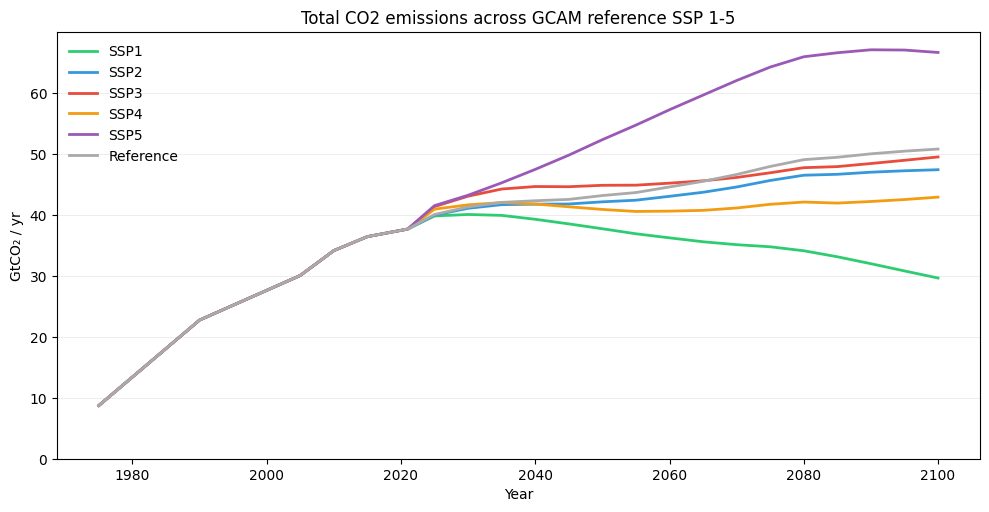

In [77]:
fig, ax = plt.subplots(figsize=(10, 5))

for scenario, grp in df.groupby('scenario'):
    base = scenario.split(',')[0]  # strip date suffix
    label = base.replace('GCAM_', '')
    if base == 'Reference':
        ax.plot(grp['Year'], grp['GtCO2'], color='#aaaaaa', linewidth=2, label='Reference')
    else:
        ax.plot(grp['Year'], grp['GtCO2'], color=SSP_COLORS[base], linewidth=2, label=label)

ax.set_xlabel('Year')
ax.set_ylabel('GtCO₂ / yr')
ax.set_ylim(0)
ax.legend(frameon=False)
ax.grid(axis='y', linewidth=0.4, alpha=0.4)

plt.tight_layout()
plt.title("Total CO2 emissions across GCAM reference SSP 1-5")
plt.savefig('../output/gcam_diagnostics/co2_total.png', dpi=150)
plt.show()

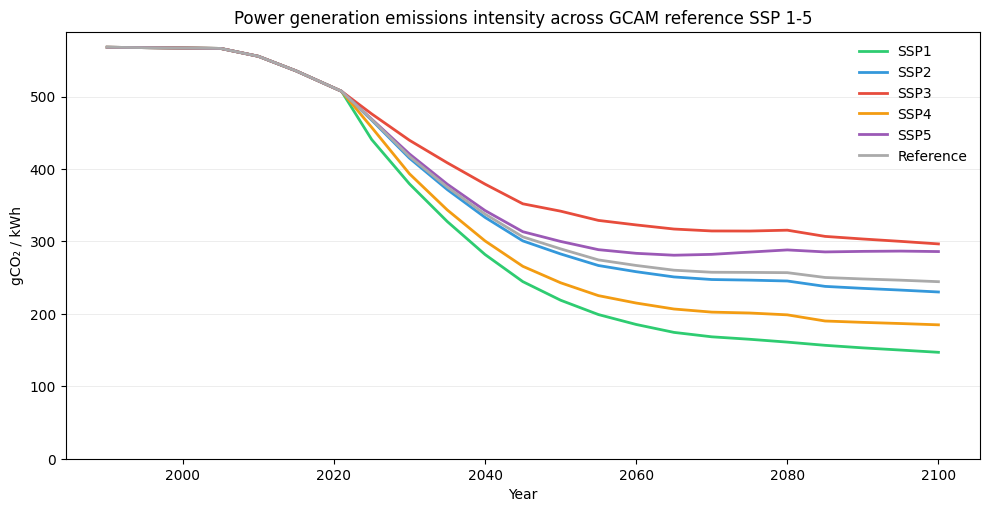

In [78]:
# --- Power sector emissions intensity ---
# CO2 from electricity generation sectors (elec_*) in MtC → MtCO2
q_elec_co2 = get_query(query_tree, 'CO2 emissions by sector (excluding resource production)', tag='emissionsQueryBuilder')
df_elec_co2_raw = conn.runQuery(q_elec_co2, scenarios=all_scenarios)

elec_sectors = [s for s in df_elec_co2_raw['sector'].unique() if s.startswith('elec_')]

df_elec_co2 = (
    df_elec_co2_raw[df_elec_co2_raw['sector'].isin(elec_sectors)]
    .groupby(['scenario', 'Year'], as_index=False)['value']
    .sum()
    .assign(MtCO2=lambda d: d['value'] * (44 / 12))
    .drop(columns='value')
)

# Electricity generation in EJ → TWh (1 EJ = 277.78 TWh)
q_elec_gen = get_query(query_tree, 'elec gen by region (incl CHP)', tag='supplyDemandQuery')
df_elec_gen_raw = conn.runQuery(q_elec_gen, scenarios=all_scenarios)

df_elec_gen = (
    df_elec_gen_raw
    .groupby(['scenario', 'Year'], as_index=False)['value']
    .sum()
    .assign(TWh=lambda d: d['value'] * 277.78)
    .drop(columns='value')
)

# Merge and compute intensity: MtCO2 / TWh = 1000 gCO2/kWh  →  ×1000 → gCO2/kWh
df_intensity = df_elec_co2.merge(df_elec_gen, on=['scenario', 'Year'])
df_intensity['gCO2_per_kWh'] = df_intensity['MtCO2'] / df_intensity['TWh'] * 1e6 / 1e9 * 1e3
# simplified: MtCO2/TWh → 1e6 tCO2 / 1e9 kWh → 1e-3 tCO2/kWh → ×1e6 → gCO2/kWh
df_intensity['gCO2_per_kWh'] = (df_intensity['MtCO2'] * 1e6) / (df_intensity['TWh'] * 1e9) * 1e6

fig, ax = plt.subplots(figsize=(10, 5))

for scenario, grp in df_intensity.groupby('scenario'):
    base = scenario.split(',')[0]
    label = base.replace('GCAM_', '')
    color = '#aaaaaa' if base == 'Reference' else SSP_COLORS.get(base, 'black')
    ax.plot(grp['Year'], grp['gCO2_per_kWh'], color=color, linewidth=2, label=label)

ax.set_xlabel('Year')
ax.set_ylabel('gCO₂ / kWh')
ax.set_ylim(0)
ax.legend(frameon=False)
ax.grid(axis='y', linewidth=0.4, alpha=0.4)

plt.tight_layout()
plt.title("Power generation emissions intensity across GCAM reference SSP 1-5")
plt.savefig('../output/gcam_diagnostics/power_intensity.png', dpi=150)
plt.show()

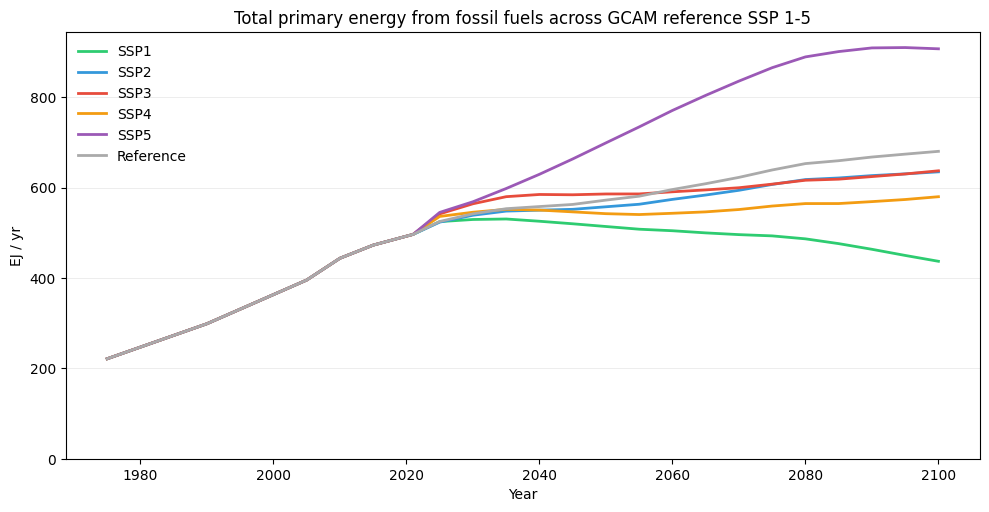

In [79]:
# --- Total primary energy from fossil fuels (coal + crude oil + natural gas) ---
q_res = get_query(query_tree, 'resource production', tag='supplyDemandQuery')
df_res_raw = conn.runQuery(q_res, scenarios=all_scenarios)

fossil_fuels = ['coal', 'crude oil', 'natural gas']
df_fossil = (
    df_res_raw[df_res_raw['resource'].isin(fossil_fuels) & (df_res_raw['Units'] == 'EJ')]
    .groupby(['scenario', 'Year'], as_index=False)['value']
    .sum()
    .rename(columns={'value': 'EJ'})
)

fig, ax = plt.subplots(figsize=(10, 5))

for scenario, grp in df_fossil.groupby('scenario'):
    base = scenario.split(',')[0]
    label = base.replace('GCAM_', '')
    color = '#aaaaaa' if base == 'Reference' else SSP_COLORS.get(base, 'black')
    ax.plot(grp['Year'], grp['EJ'], color=color, linewidth=2, label=label)

ax.set_xlabel('Year')
ax.set_ylabel('EJ / yr')
ax.set_ylim(0)
ax.legend(frameon=False)
ax.grid(axis='y', linewidth=0.4, alpha=0.4)

plt.tight_layout()
plt.title("Total primary energy from fossil fuels across GCAM reference SSP 1-5")
plt.savefig('../output/gcam_diagnostics/fossil_primary_energy.png', dpi=150)
plt.show()